# 02 · Elasticity, Supply & Demand

Notebook 01 ended on a question a predictor can't answer: *how does demand **respond** when I change price?* That response is the **price elasticity of demand**, and it is the heart of pricing.

$$\varepsilon = \frac{\% \Delta Q}{\% \Delta P} = \frac{d\ln Q}{d\ln P}$$

- **Elastic** ($|\varepsilon| > 1$): quantity reacts strongly → *cutting* price can raise revenue (lots of substitutes, e.g. one seller of a commodity).
- **Inelastic** ($|\varepsilon| < 1$): quantity barely reacts → *raising* price raises revenue (necessities, few substitutes).

This is exactly why **surge pricing** works on Uber and why **Smart Pricing** matters on Airbnb: the revenue-maximising price depends on *where on the demand curve you are*.

**References**
- [Uber — The Economics of Surge Pricing](https://www.uber.com/blog/research/the-economics-of-surge-pricing/)
- [Castillo — Who Benefits from Surge Pricing? (PDF)](https://economics.sas.upenn.edu/system/files/2020-01/JMP_Castillo.pdf)
- [Causal Inference for the Brave and True — price elasticity](https://matheusfacure.github.io/python-causality-handbook/)

In [1]:
import sys, os
sys.path.append(os.path.abspath('utils'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datagen import simulate_demand_curve, simulate_linear_market, ELASTICITY_PRESETS, demand_at_price

## 1. Constant-elasticity demand curves

$Q = A \cdot P^{\varepsilon}$. We plot several presets, from very inelastic to very elastic.

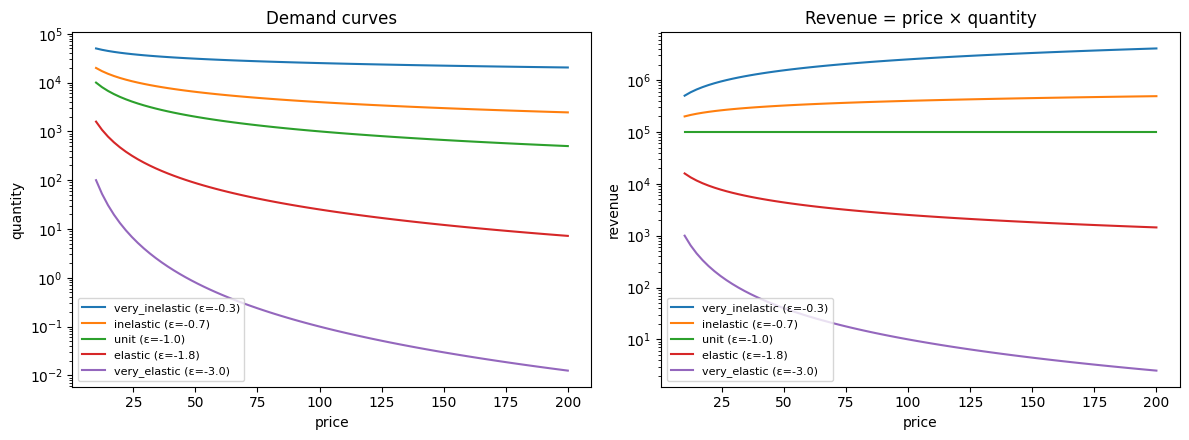

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
prices = np.linspace(10, 200, 80)
for name, eps in ELASTICITY_PRESETS.items():
    q = demand_at_price(prices, eps)
    ax[0].plot(prices, q, label=f'{name} (ε={eps})')
    ax[1].plot(prices, prices*q, label=f'{name} (ε={eps})')
ax[0].set_title('Demand curves'); ax[0].set_xlabel('price'); ax[0].set_ylabel('quantity'); ax[0].set_yscale('log'); ax[0].legend(fontsize=8)
ax[1].set_title('Revenue = price × quantity'); ax[1].set_xlabel('price'); ax[1].set_ylabel('revenue'); ax[1].set_yscale('log'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. The total-revenue test

Where does revenue go as we raise price? Elastic goods *lose* revenue when price rises; inelastic goods *gain* it. This is the single most important intuition in pricing.

In [3]:
for label, eps in [('inelastic', -0.7), ('elastic', -1.8)]:
    curve, gt = simulate_demand_curve(elasticity=eps, p_min=10, p_max=200, n_points=60)
    lo, hi = curve['revenue'].iloc[0], curve['revenue'].iloc[-1]
    direction = 'RISES' if hi > lo else 'FALLS'
    print(f'{label:>10} (ε={eps}): revenue {direction} as price goes $10 → $200  '
          f'(${lo:,.0f} → ${hi:,.0f})')

# Sanity: inelastic revenue rises with price, elastic revenue falls.
ine, _ = simulate_demand_curve(elasticity=-0.7); ela, _ = simulate_demand_curve(elasticity=-1.8)
assert ine['revenue'].iloc[-1] > ine['revenue'].iloc[0]
assert ela['revenue'].iloc[-1] < ela['revenue'].iloc[0]
print('\n✓ Inelastic → price up = revenue up. Elastic → price up = revenue down.')

 inelastic (ε=-0.7): revenue RISES as price goes $10 → $200  ($199,526 → $490,127)
   elastic (ε=-1.8): revenue FALLS as price goes $10 → $200  ($15,849 → $1,443)

✓ Inelastic → price up = revenue up. Elastic → price up = revenue down.


## 3. Supply, demand & market equilibrium

A marketplace has **two** curves. Price gravitates to where supply meets demand. A demand spike (or supply drop) moves the equilibrium price up — the mechanical basis of **surge**.

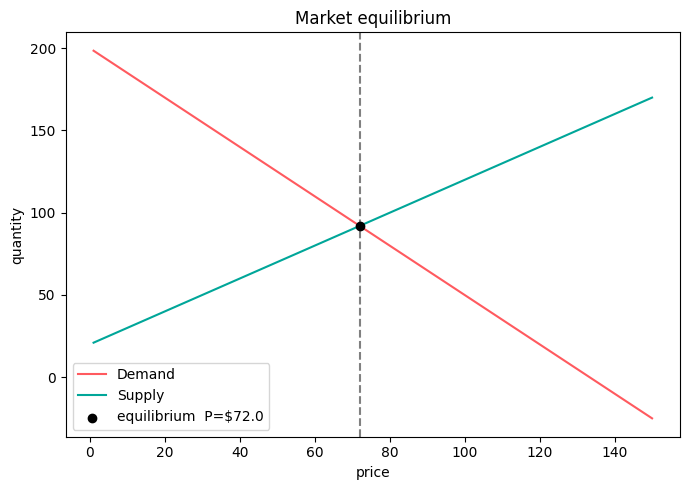

Equilibrium: 72.0 92.0


In [4]:
mkt, gt = simulate_linear_market()
plt.figure(figsize=(7,5))
plt.plot(mkt['price'], mkt['quantity_demanded'], label='Demand', color='#FF5A5F')
plt.plot(mkt['price'], mkt['quantity_supplied'], label='Supply', color='#00A699')
plt.axvline(gt['equilibrium_price'], ls='--', color='gray')
plt.scatter([gt['equilibrium_price']],[gt['equilibrium_quantity']], color='black', zorder=5,
            label=f"equilibrium  P=${gt['equilibrium_price']:.1f}")
plt.xlabel('price'); plt.ylabel('quantity'); plt.title('Market equilibrium'); plt.legend(); plt.tight_layout(); plt.show()
print('Equilibrium:', gt['equilibrium_price'], gt['equilibrium_quantity'])

## 4. The trap we are about to walk into

Estimating elasticity *looks* like a one-line regression: collect prices and quantities, fit $\ln Q$ on $\ln P$, read off the slope. But the data we observe is the sequence of **equilibrium points** in section 3 — each one is where *both* supply and demand happened to cross. The prices we see are not random; they move *with* demand.

Run that naive regression and you will not recover the demand elasticity — you will recover a meaningless blend of supply and demand. That is the **endogeneity / simultaneity** problem, and fixing it is the entire job of [notebook 03](03_causal_problem_endogeneity.ipynb).